In [2]:
import shap
import numpy as np
from stable_baselines3 import PPO
import pandas as pd
from all_obs_env.all_obs_env import InterfaceEnv
import gymnasium as gym
import matplotlib.pyplot as plt
shap.initjs()

In [3]:
def _state_to_obs(state):
    obs = {
        'Time': np.array([state[-4]], dtype=np.float32),
        'User': int(state[-3]),
        'shift': int(state[-2][1])-1,
        'dayofweek': int(state[-1])

    }
    return obs

In [4]:
class PPOExplainer:
    def __init__(self, model):
        self.model = model
    
    def predict_proba(self, X):
        """Devuelve probabilidades de acciones (para clasificación)"""
        return np.array([self.model.policy.predict(obs, deterministic=True)[1]['probs'] 
                         for obs in X])
    
    def predict(self, X):
        """Devuelve acciones (para regresión)"""
        return np.array([self.model.predict(obs, deterministic=True)[0] 
                         for obs in X])

In [50]:
df = pd.read_csv(r'../data/cooked_test.csv')
df.loc[df['shift'] == 'out', 'shift'] = 't1'
env = InterfaceEnv(df)
model = PPO.load(r'C:\Users\manex\OneDrive - Mondragon Unibertsitatea\Unibertsitatea\3.kurtsoa\Lana\Mixing-machine\Python\Version_9_txukuna\RLHF_adaptation\new_data_all1.zip')

Data collection

In [39]:
background_data_df = df

In [41]:
background_data = background_data_df[['hora_decimal', 'encoded_user', 'shift', 'initdayofweek']].values
samples = []
for data in background_data:
    samples.append(_state_to_obs(data))

samples = np.array(samples)

In [42]:
samples

array([{'Time': array([13.364445], dtype=float32), 'User': 21, 'shift': 1, 'dayofweek': 0},
       {'Time': array([12.465834], dtype=float32), 'User': 0, 'shift': 1, 'dayofweek': 4},
       {'Time': array([10.343797], dtype=float32), 'User': 28, 'shift': 0, 'dayofweek': 0},
       {'Time': array([9.431666], dtype=float32), 'User': 19, 'shift': 0, 'dayofweek': 2},
       {'Time': array([6.4483333], dtype=float32), 'User': 13, 'shift': 0, 'dayofweek': 0},
       {'Time': array([11.405833], dtype=float32), 'User': 13, 'shift': 0, 'dayofweek': 2},
       {'Time': array([11.498055], dtype=float32), 'User': 17, 'shift': 0, 'dayofweek': 3},
       {'Time': array([9.026667], dtype=float32), 'User': 19, 'shift': 0, 'dayofweek': 3},
       {'Time': array([11.0830555], dtype=float32), 'User': 17, 'shift': 0, 'dayofweek': 1},
       {'Time': array([6.5052776], dtype=float32), 'User': 9, 'shift': 0, 'dayofweek': 3},
       {'Time': array([10.815], dtype=float32), 'User': 3, 'shift': 0, 'dayofweek':

In [9]:
samples.shape

(352,)

In [134]:
action = list(model.predict(samples[6]))[0]
action

array([10, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,  8,  1,
        0], dtype=int64)

In [135]:
class PPO_SHAP_Wrapper:
    def __init__(self, model):
        self.model = model
    
    def predict(self, X):
        """X debe ser un array 2D (n_samples, n_features)"""
        return np.array([self.model.predict(_state_to_obs(obs), deterministic=True)[0] for obs in X])

In [145]:
feature_names = ['hora_decimal', 'encoded_user', 'shift', 'initdayofweek']
accion_idx = -2

In [138]:
explainer = shap.KernelExplainer(
    PPO_SHAP_Wrapper(model).predict,
    background_data[:50],
    link="identity"
)

In [55]:
shap_values_all = explainer.shap_values(background_data[0:1], nsamples=50)  

  0%|          | 0/1 [00:00<?, ?it/s]

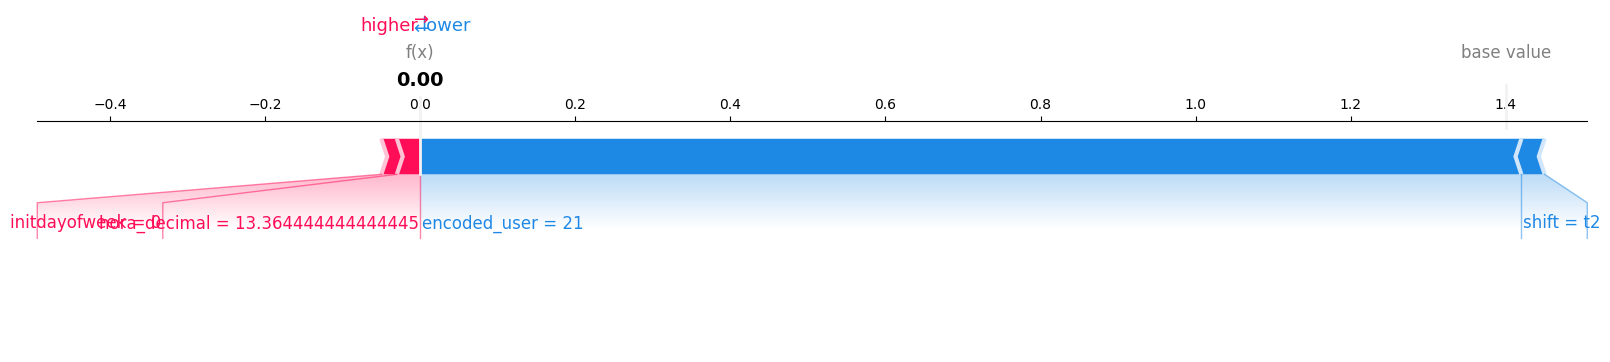

In [147]:
base_value = explainer.expected_value[accion_idx]

# 2. Los valores SHAP para la instancia 0 y la acción elegida.
shap_values_1D = shap_values_all[0, :, accion_idx]

# 3. Los valores de las características para la instancia 0.
#    Esto ya es un array 1D de forma (4,)
features_1D = background_data[0]

shap.force_plot(
    base_value,
    shap_values_1D,
    features_1D,
    feature_names=feature_names,
    matplotlib=True 
)
plt.show()

In [140]:

shap_values_summary = explainer.shap_values(background_data[:50], nsamples=50)

  0%|          | 0/50 [00:00<?, ?it/s]

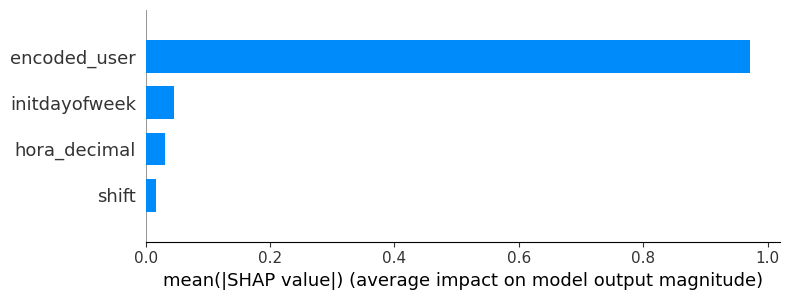

In [148]:
shap.summary_plot(
    shap_values_summary[:, :, accion_idx],  # SHAP values para la acción 4
    background_data[:50],                   # Datos de las características originales
    feature_names=feature_names,
    plot_type="bar",                    
)
plt.show()

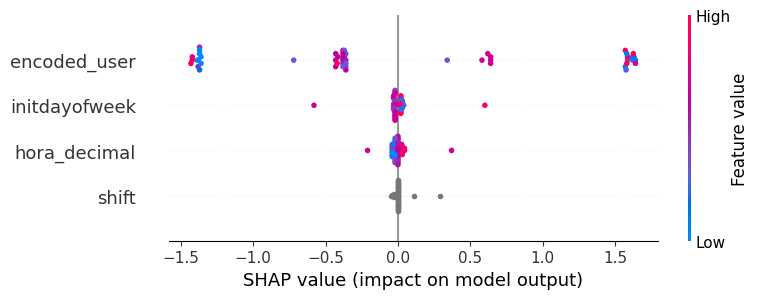

In [146]:
shap.summary_plot(
    shap_values_summary[:, :, accion_idx], 
    background_data[:50],                   
    feature_names=feature_names,
    plot_type="dot",                    
)
plt.show()